### Importing the libraries

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
from tabulate import tabulate
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import GridSearchCV

### Load data from CSV file

In [73]:
restaurants_df = pd.read_csv("../Foursquare/final_restaurants_dataset_cleaned.csv")
coffeeshops_df = pd.read_csv("../Foursquare/final_coffeeshops_dataset_cleaned.csv")
print(restaurants_df.info())
print(coffeeshops_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1221 entries, 0 to 1220
Data columns (total 36 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business ID                               1221 non-null   object 
 1   Name                                      1221 non-null   object 
 2   Latitude                                  1221 non-null   float64
 3   Longitude                                 1221 non-null   float64
 4   Category                                  1221 non-null   object 
 5   Rating                                    1221 non-null   object 
 6   Popularity                                1221 non-null   float64
 7   Google Place ID                           1221 non-null   object 
 8   Business Status                           1221 non-null   object 
 9   Distance (m)                              1221 non-null   float64
 10  Cluster                             

### Combine and convert generalCategory to numerical

In [74]:
combined_df = pd.concat([coffeeshops_df, restaurants_df], ignore_index=True)
combined_df["generalCategory"] = combined_df["generalCategory"].map({"coffee shop": 0, "restaurant": 1})

# Pre-processing

### Outlires functions

In [75]:
def remove_outliers_IQR(X, y):
    """Remove outliers using IQR."""
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (y >= lower_bound) & (y <= upper_bound)
    return X[mask], y[mask]

In [76]:
def remove_outliers(df, threshold=3):
    """Remove outliers using the Z-score method while handling NaN values."""
    
    # Compute mean and standard deviation for numerical columns
    mean = df.mean(numeric_only=True)
    std = df.std(numeric_only=True)
    
    # Avoid division by zero for constant columns
    std_replaced = std.replace(0, np.nan)  

    # Compute Z-score
    z_scores = np.abs((df - mean) / std_replaced)

    # Keep rows where all columns are within the threshold
    return df[(z_scores < threshold).all(axis=1)].dropna()

### Correlation Function 

In [77]:
def remove_highly_correlated_features(X, threshold=0.95):
    """Remove features that are highly correlated with each other."""
    X_df = pd.DataFrame(X)
    corr_matrix = X_df.corr().abs()
    
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    return X_df.drop(columns=to_drop, errors='ignore')

### info and null values

In [78]:
combined_df.info()
print(combined_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1910 entries, 0 to 1909
Data columns (total 36 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business ID                               1910 non-null   object 
 1   Name                                      1910 non-null   object 
 2   Latitude                                  1910 non-null   float64
 3   Longitude                                 1910 non-null   float64
 4   Category                                  1910 non-null   object 
 5   Rating                                    1910 non-null   object 
 6   Popularity                                1910 non-null   float64
 7   Google Place ID                           1909 non-null   object 
 8   Business Status                           1910 non-null   object 
 9   Distance (m)                              1910 non-null   float64
 10  Cluster                             

### Histograms

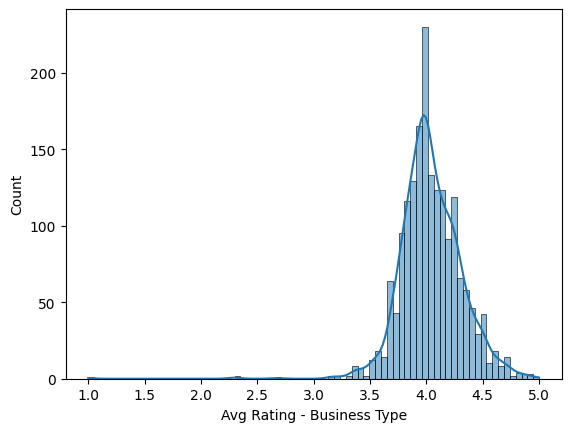

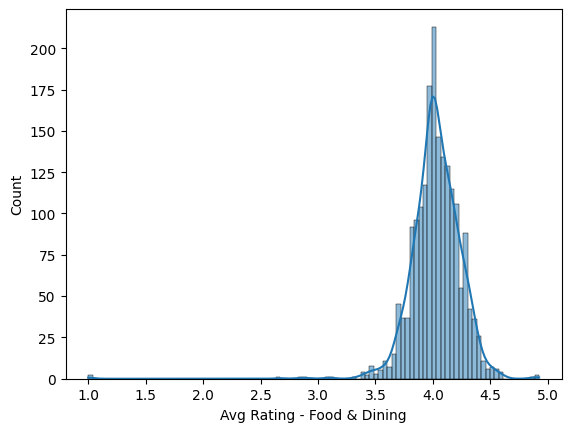

In [79]:
sns.histplot(combined_df["Avg Rating - Business Type"], kde=True)
plt.show()
sns.histplot(combined_df["Avg Rating - Food & Dining"], kde=True)
plt.show()


### Filling missing values with the median

In [80]:
combined_df["Avg Rating - Business Type"] = combined_df["Avg Rating - Business Type"].fillna(combined_df["Avg Rating - Business Type"].median())
combined_df["Avg Rating - Food & Dining"] = combined_df["Avg Rating - Food & Dining"].fillna(combined_df["Avg Rating - Food & Dining"].median())

### Drop irrelevent columns

In [81]:
irrelevant_columns = ['Business ID', 'Latitude'	, 'Longitude', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 'Competition - Food & Dining/Area',
                'Competition - Business Type/POI Density', 'Competition - Food & Dining/POI Density', 'Competition - Business Type/related POIs'
               , 'Competition - Food & Dining/POI Density']
combined_df.drop(columns=irrelevant_columns, inplace=True)

# SVR model (All features)

In [82]:
competition_cols = [
    "Competition - Business Type/Area",
    "Competition - Food & Dining/Area",
    "Competition - Business Type/POI Density",
    "Competition - Food & Dining/POI Density",
    "Competition - Business Type/related POIs",
    "Competition - Food & Dining/related POIs"
]

avg_rating_cols = ["Avg Rating - Business Type", "Avg Rating - Food & Dining"]

target_col = "Popularity"

In [83]:
print(list(combined_df.columns))

['Popularity', 'generalCategory', 'Religious Institutions', 'Coffee Shops', 'Food & Dining', 'Restaurants', 'Home & Construction Services', 'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services', 'Education', 'Health', 'Public & Government Services', 'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness', 'POI Density', 'Avg Rating - Food & Dining', 'Competition - Food & Dining/related POIs', 'Population Within 1km']


# SVR (normalize all then scale features)

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro, probplot
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, max_error

# Function to remove highly correlated features
def remove_highly_correlated_features(X, threshold=0.95):
    """Removes highly correlated features from X."""
    corr_matrix = X.corr().abs()  # Compute absolute correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Upper triangle

    # Find columns to drop
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return X.drop(columns=to_drop, errors='ignore'), to_drop  # Drop and return removed features

results = []

# Assuming combined_df is your DataFrame
transformed_df = combined_df.copy()

# Remove outliers in 'Popularity' using IQR method
Q1 = transformed_df['Popularity'].quantile(0.25)
Q3 = transformed_df['Popularity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

num_cols = transformed_df.select_dtypes(include=['number']).columns

# Apply PowerTransformer (normalize distribution)
power_transformer = PowerTransformer()
transformed_df[num_cols] = power_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
minmax_scaler = MinMaxScaler()
transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])


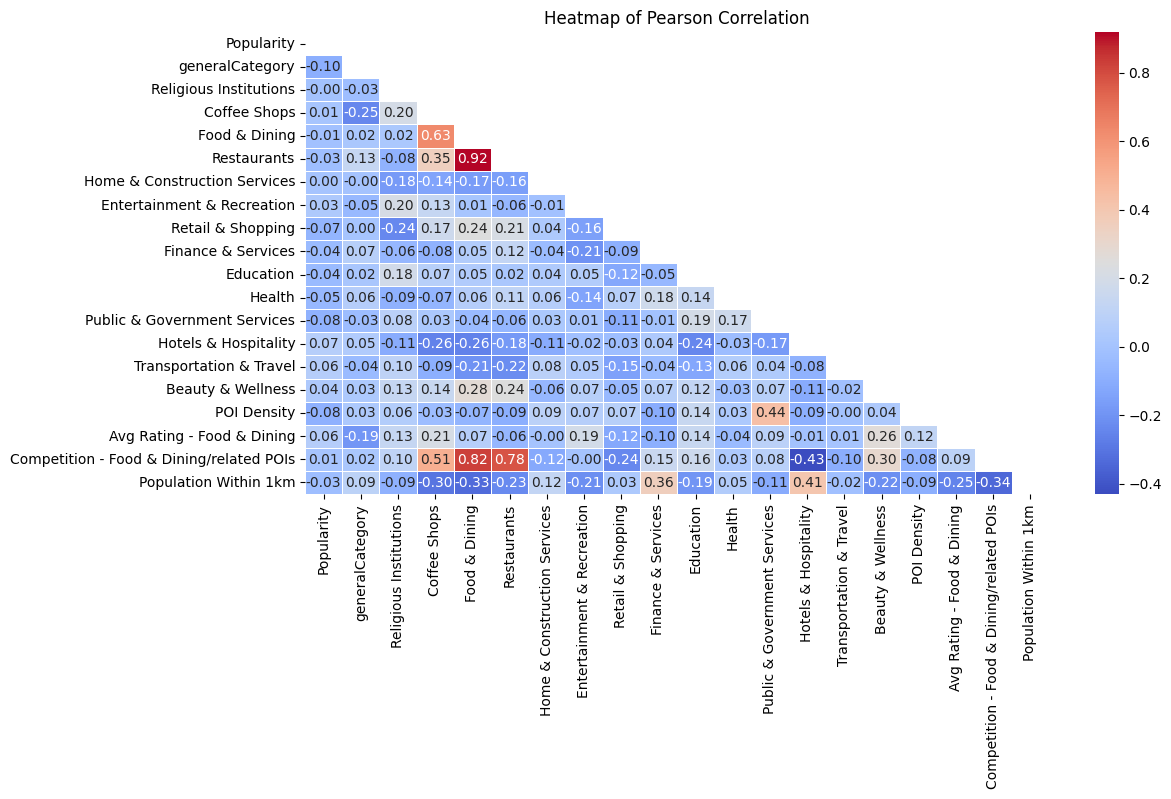

In [85]:
# Compute Pearson correlation for scaled data
corr_matrix = transformed_df.corr()

# Create a mask for the upper triangular part
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Heatmap of Pearson Correlation")
plt.show()

## SVR MODEL EXP 1 

In [86]:
# Define features (X) and target variable (y)
X = transformed_df.drop(columns=['Popularity'])
y = transformed_df['Popularity']

feature_cols = [
    "Religious Institutions", "Coffee Shops", "Food & Dining", "Restaurants", 
    "Home & Construction Services", "Entertainment & Recreation", "Retail & Shopping",
    "Finance & Services", "Education", "Health", "Public & Government Services",
    "Hotels & Hospitality", "Transportation & Travel", "Beauty & Wellness", "POI Density",
    "Avg Rating - Food & Dining", "Competition - Food & Dining/related POIs",
    "Population Within 1km"
]

print(X.columns)
# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")
    
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
param_grid = {
    'svr__regressor__C': [0.01, 0.1, 1, 10],
    'svr__regressor__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'svr__regressor__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__regressor__kernel': ['rbf', 'sigmoid']
}

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")


# Set up the pipeline
model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', TransformedTargetRegressor(
        regressor=SVR(),
        transformer=PowerTransformer()
    ))
])

# Replace negative or zero values to avoid PowerTransformer issues
X[X <= 0] = 1e-6

# Check for NaNs or Infs before splitting
check_nan_inf(X, y)

grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='r2')

grid_search.fit(X_train, y_train)

# Check for NaNs in grid search results
if np.isnan(grid_search.cv_results_['mean_test_score']).any():
    print("Warning: NaN values found in GridSearchCV results. Check your data and parameter grid.")

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")


Index(['generalCategory', 'Religious Institutions', 'Coffee Shops',
       'Food & Dining', 'Restaurants', 'Home & Construction Services',
       'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services',
       'Education', 'Health', 'Public & Government Services',
       'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness',
       'POI Density', 'Avg Rating - Food & Dining',
       'Competition - Food & Dining/related POIs', 'Population Within 1km'],
      dtype='object')
Removed highly correlated features: ['Restaurants']
Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best parameters found:  {'svr__regressor__C': 0.1, 'svr__regressor__epsilon': 0.05, 'svr__regressor__gamma': 'scale', 'svr__regressor__kernel': 'rbf'}
Best score (MSE):  0.002471253661126482
Predictions on test data completed with the best model.
Metric          │      Value
-----------------------------------
RMSE            │     0.2882
MSE             │     0.0831
MAE 

## SVR MODEL EXP 2

In [87]:
# Define features (X) and target variable (y)
X = transformed_df[['POI Density', 'Avg Rating - Food & Dining', 'Competition - Food & Dining/related POIs', 'Population Within 1km']]
y = transformed_df['Popularity']

print(X.columns)
# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")
    
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
param_grid = {
    'svr__regressor__C': [0.01, 0.1, 1, 10],
    'svr__regressor__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'svr__regressor__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__regressor__kernel': ['rbf', 'sigmoid']
}

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")


# Set up the pipeline
model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', TransformedTargetRegressor(
        regressor=SVR(),
        transformer=PowerTransformer()
    ))
])

# Replace negative or zero values to avoid PowerTransformer issues
X[X <= 0] = 1e-6

# Check for NaNs or Infs before splitting
check_nan_inf(X, y)

grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='r2')

grid_search.fit(X_train, y_train)

# Check for NaNs in grid search results
if np.isnan(grid_search.cv_results_['mean_test_score']).any():
    print("Warning: NaN values found in GridSearchCV results. Check your data and parameter grid.")

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")


Index(['POI Density', 'Avg Rating - Food & Dining',
       'Competition - Food & Dining/related POIs', 'Population Within 1km'],
      dtype='object')
Removed highly correlated features: []
Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best parameters found:  {'svr__regressor__C': 0.1, 'svr__regressor__epsilon': 0.05, 'svr__regressor__gamma': 'scale', 'svr__regressor__kernel': 'rbf'}
Best score (MSE):  0.012372930180701314
Predictions on test data completed with the best model.
Metric          │      Value
-----------------------------------
RMSE            │     0.2941
MSE             │     0.0865
MAE             │     0.2443
R²              │    -0.0376
MedAE           │     0.2229
Max Error       │     0.7056
MAD             │     0.2440
Model evaluation completed!


In [88]:

# Define features (X) and target variable (y)
X = transformed_df.drop(columns=['Popularity'])
y = transformed_df['Popularity']

# Remove Outliers
#num_outliers_before = X.shape[0]
#X, y = remove_outliers(X, y)
#num_outliers_removed = num_outliers_before - X.shape[0]
#print(f"Number of data points removed as outliers: {num_outliers_removed}")

# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")
    
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
# Set up refined Grid Search
param_grid = {
    'svr__regressor__C': [0.01, 0.1, 1, 10],
    'svr__regressor__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'svr__regressor__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__regressor__kernel': ['rbf', 'sigmoid']
}

# Function to remove outliers using IQR
def remove_outliers_IQR(X, y):
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (y >= lower_bound) & (y <= upper_bound)
    return X[mask], y[mask]

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")

feature_cols = [
    "Religious Institutions", "Coffee Shops", "Food & Dining", "Restaurants", 
    "Home & Construction Services", "Entertainment & Recreation", "Retail & Shopping",
    "Finance & Services", "Education", "Health", "Public & Government Services",
    "Hotels & Hospitality", "Transportation & Travel", "Beauty & Wellness", "POI Density",
    "Avg Rating - Food & Dining", "Competition - Food & Dining/related POIs",
    "Population Within 1km"
]

# Set up the pipeline
model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', TransformedTargetRegressor(
        regressor=SVR(),
        transformer=PowerTransformer()
    ))
])

# Replace negative or zero values to avoid PowerTransformer issues
X[X <= 0] = 1e-6

# Check for NaNs or Infs before splitting
check_nan_inf(X, y)

grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='r2')

grid_search.fit(X_train, y_train)

# Check for NaNs in grid search results
if np.isnan(grid_search.cv_results_['mean_test_score']).any():
    print("Warning: NaN values found in GridSearchCV results. Check your data and parameter grid.")

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")

# Let me know if you’d like me to refine anything else! 🚀

Removed highly correlated features: ['Restaurants']
Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best parameters found:  {'svr__regressor__C': 0.1, 'svr__regressor__epsilon': 0.05, 'svr__regressor__gamma': 'scale', 'svr__regressor__kernel': 'rbf'}
Best score (MSE):  0.002471253661126482
Predictions on test data completed with the best model.
Metric          │      Value
-----------------------------------
RMSE            │     0.2882
MSE             │     0.0831
MAE             │     0.2364
R²              │     0.0035
MedAE           │     0.2062
Max Error       │     0.6925
MAD             │     0.2440
Model evaluation completed!


In [89]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
import numpy as np

# Ensure model is defined and trained before this
# Predictions
y_pred = model.predict(X_test)
print(y_pred.shape)

# Compute Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))  # Mean Absolute Deviation

# Print Results in Table Format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")


NotFittedError: This MinMaxScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

### Correlation matrix

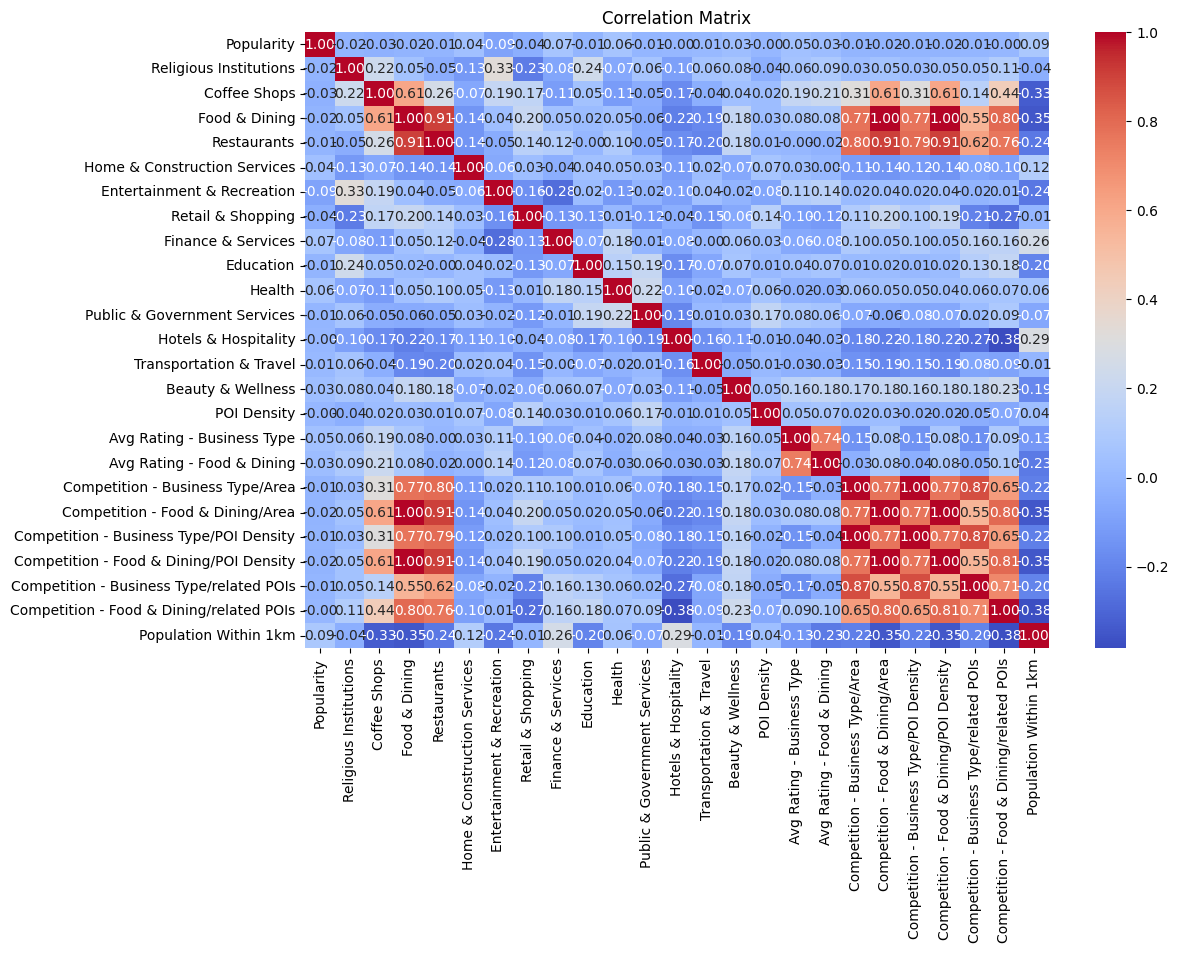

In [ ]:
# Compute the correlation matrix
corr_matrix = combined_df.corr()
 
# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
import numpy as np

# Predictions
y_pred = best_model.predict(X)

# Compute Metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)
medae = median_absolute_error(y, y_pred)
max_err = max_error(y, y_pred)
mad = np.mean(np.abs(y - np.mean(y)))  # Mean Absolute Deviation

# Print Results in Table Format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

Metric          │      Value
-----------------------------------
RMSE            │     0.2539
MSE             │     0.0644
MAE             │     0.2080
R²              │     0.2542
MedAE           │     0.1896
Max Error       │     0.6267
MAD             │     0.2528


# SVR (z-score outlier and high correlation removed)

In [ ]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
import numpy as np
import pandas as pd
from tabulate import tabulate

results = []
for col in competition_cols:
    for rating_col in avg_rating_cols:
        if col not in combined_df.columns or rating_col not in combined_df.columns:
            continue

        # Remove outliers
        combined_df_clean = remove_outliers(combined_df)

        # Select features dynamically for each iteration
        X = combined_df_clean.drop(columns=['Popularity'] + 
                                   [c for c in competition_cols if c != col] + 
                                   [r for r in avg_rating_cols if r != rating_col], 
                                   errors='ignore')
        y = combined_df_clean['Popularity']

        # Remove highly correlated features
        X_filtered = remove_highly_correlated_features(X, threshold=0.95)

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

        # Train SVR model
        model = SVR(kernel='rbf', C=100, gamma=2.0, epsilon=0.05)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Compute metrics
        metrics = {
            "Competition Factor": col,
            "Rating Factor": rating_col,
            "Feature Count": len(X_filtered.columns),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MSE": mean_squared_error(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R²": r2_score(y_test, y_pred),
            "MedAE": median_absolute_error(y_test, y_pred),
            "Max Error": max_error(y_test, y_pred),
            "MAD": np.median(np.abs(y_test - np.median(y_test))) 
        }
        results.append(metrics)

# Display Results for Each Competition Factor
print("\nFinal Metrics Comparison Table:")
print(tabulate(results, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))



Final Metrics Comparison Table:
╒══════════════════════════════════════════╤════════════════════════════╤═════════════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤═════════════╤══════════╕
│ Competition Factor                       │ Rating Factor              │   Feature Count │     RMSE │      MSE │      MAE │        R² │    MedAE │   Max Error │      MAD │
╞══════════════════════════════════════════╪════════════════════════════╪═════════════════╪══════════╪══════════╪══════════╪═══════════╪══════════╪═════════════╪══════════╡
│ Competition - Business Type/Area         │ Avg Rating - Business Type │              19 │ 0.102415 │ 0.010489 │ 0.073150 │ -0.109301 │ 0.066625 │    0.580010 │ 0.017556 │
├──────────────────────────────────────────┼────────────────────────────┼─────────────────┼──────────┼──────────┼──────────┼───────────┼──────────┼─────────────┼──────────┤
│ Competition - Business Type/Area         │ Avg Rating - Food & Dining │              19 │ 0.102415 │

# SVR (IQR outlier and high correlation removed)

In [ ]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
import numpy as np
import pandas as pd
from tabulate import tabulate

results = []
for col in competition_cols:
    for rating_col in avg_rating_cols:
        if col not in combined_df.columns or rating_col not in combined_df.columns:
            continue

        # Select features dynamically for each iteration
        X = combined_df.drop(columns=['Popularity'] + 
                              [c for c in competition_cols if c != col] + 
                              [r for r in avg_rating_cols if r != rating_col], 
                              errors='ignore')
        y = combined_df['Popularity'].values  

        # Remove outliers
        X_filtered, y_filtered = remove_outliers_IQR(X.to_numpy(), y)

        # Debugging Step: Check shape variations
        #print(f"After outlier removal for {col} - {rating_col}: X shape={X_filtered.shape}, y shape={len(y_filtered)}")

        # Ensure both X and y have the same number of samples
        if X_filtered.shape[0] != len(y_filtered):
            print(f"Skipping {col} - {rating_col} due to mismatched samples after outlier removal.")
            continue

        # Convert back to DataFrame
        X_filtered = pd.DataFrame(X_filtered, columns=X.columns)

        # Remove highly correlated features
        X_filtered = remove_highly_correlated_features(X_filtered, threshold=0.95)

        # Debugging Step: Check if feature count is changing
        #print(f"Features used for {col} - {rating_col}: {len(X_filtered.columns)} features")

        # Shuffle dataset before splitting
        shuffled_df = X_filtered.copy()
        shuffled_df['Popularity'] = y_filtered
        shuffled_df = shuffled_df.sample(frac=1, random_state=None).reset_index(drop=True)

        # Extract updated X and y
        X_final = shuffled_df.drop(columns=['Popularity'])
        y_final = shuffled_df['Popularity']

        # Debugging Step: Check variation in Popularity
        #print(f"Min y={y_final.min()}, Max y={y_final.max()}")

        # Train-test split (random_state=None for different splits)
        X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=None)

        # Train SVR model
        model = SVR(kernel='rbf', C=100, gamma=2.0, epsilon=0.05)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Compute metrics
        metrics = {
            "Competition Factor": col,
            "Rating Factor": rating_col,
            "Unique Features Used": len(X_final.columns),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MSE": mean_squared_error(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R²": r2_score(y_test, y_pred),
            "MedAE": median_absolute_error(y_test, y_pred),
            "Max Error": max_error(y_test, y_pred),
            "MAD": np.median(np.abs(y_test - np.median(y_test))) 
        }
        results.append(metrics)

# Display Results for Each Competition Factor
print("\nFinal Metrics Comparison Table:")
print(tabulate(results, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))



Final Metrics Comparison Table:
╒══════════════════════════════════════════╤════════════════════════════╤════════════════════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤═════════════╤══════════╕
│ Competition Factor                       │ Rating Factor              │   Unique Features Used │     RMSE │      MSE │      MAE │        R² │    MedAE │   Max Error │      MAD │
╞══════════════════════════════════════════╪════════════════════════════╪════════════════════════╪══════════╪══════════╪══════════╪═══════════╪══════════╪═════════════╪══════════╡
│ Competition - Business Type/Area         │ Avg Rating - Business Type │                     19 │ 0.041341 │ 0.001709 │ 0.038055 │ -0.538232 │ 0.040238 │    0.083949 │ 0.015091 │
├──────────────────────────────────────────┼────────────────────────────┼────────────────────────┼──────────┼──────────┼──────────┼───────────┼──────────┼─────────────┼──────────┤
│ Competition - Business Type/Area         │ Avg Rating - Food & Di

# SVR (all features - IQR outlier and high correlation removed) with scaling

#### Standard Scaling

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
import numpy as np
import pandas as pd
from tabulate import tabulate

results = []
for col in competition_cols:
    for rating_col in avg_rating_cols:
        if col not in combined_df.columns or rating_col not in combined_df.columns:
            continue

        # Select features dynamically for each iteration
        X = combined_df.drop(columns=['Popularity'] + 
                              [c for c in competition_cols if c != col] + 
                              [r for r in avg_rating_cols if r != rating_col], 
                              errors='ignore')
        y = combined_df['Popularity'].values  

        # Remove outliers
        X_filtered, y_filtered = remove_outliers_IQR(X.to_numpy(), y)

        # Ensure both X and y have the same number of samples
        if X_filtered.shape[0] != len(y_filtered):
            print(f"Skipping {col} - {rating_col} due to mismatched samples after outlier removal.")
            continue

        # Convert back to DataFrame
        X_filtered = pd.DataFrame(X_filtered, columns=X.columns)

        # Remove highly correlated features
        X_filtered = remove_highly_correlated_features(X_filtered, threshold=0.95)

        # Shuffle dataset before splitting
        shuffled_df = X_filtered.copy()
        shuffled_df['Popularity'] = y_filtered
        shuffled_df = shuffled_df.sample(frac=1, random_state=None).reset_index(drop=True)

        # Extract updated X and y
        X_final = shuffled_df.drop(columns=['Popularity'])
        y_final = shuffled_df['Popularity']

        # Scale features
        X_scaler = StandardScaler()
        X_scaled = X_scaler.fit_transform(X_final)

        # Train-test split (random_state=None for different splits)
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_final, test_size=0.2, random_state=None)

        # Train SVR model
        model = SVR(kernel='rbf', C=100, gamma=2.0, epsilon=0.05)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Compute metrics
        metrics = {
            "Competition Factor": col,
            "Rating Factor": rating_col,
            "Unique Features Used": len(X_final.columns),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MSE": mean_squared_error(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R²": r2_score(y_test, y_pred),
            "MedAE": median_absolute_error(y_test, y_pred),
            "Max Error": max_error(y_test, y_pred),
            "MAD": np.median(np.abs(y_test - np.median(y_test))) 
        }
        results.append(metrics)

# Display Results for Each Competition Factor
print("\nFinal Metrics Comparison Table:")
print(tabulate(results, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))



Final Metrics Comparison Table:
╒══════════════════════════════════════════╤════════════════════════════╤════════════════════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤═════════════╤══════════╕
│ Competition Factor                       │ Rating Factor              │   Unique Features Used │     RMSE │      MSE │      MAE │        R² │    MedAE │   Max Error │      MAD │
╞══════════════════════════════════════════╪════════════════════════════╪════════════════════════╪══════════╪══════════╪══════════╪═══════════╪══════════╪═════════════╪══════════╡
│ Competition - Business Type/Area         │ Avg Rating - Business Type │                     19 │ 0.040013 │ 0.001601 │ 0.036049 │ -0.370259 │ 0.038977 │    0.084106 │ 0.018125 │
├──────────────────────────────────────────┼────────────────────────────┼────────────────────────┼──────────┼──────────┼──────────┼───────────┼──────────┼─────────────┼──────────┤
│ Competition - Business Type/Area         │ Avg Rating - Food & Di

#### Robust Scaling

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
import numpy as np
import pandas as pd
from tabulate import tabulate

results = []
for col in competition_cols:
    for rating_col in avg_rating_cols:
        if col not in combined_df.columns or rating_col not in combined_df.columns:
            continue

        # Select features dynamically for each iteration
        X = combined_df.drop(columns=['Popularity'] + 
                              [c for c in competition_cols if c != col] + 
                              [r for r in avg_rating_cols if r != rating_col], 
                              errors='ignore')
        y = combined_df['Popularity'].values  

        # Remove outliers
        X_filtered, y_filtered = remove_outliers_IQR(X.to_numpy(), y)

        # Debugging Step: Check shape variations
        print(f"After outlier removal for {col} - {rating_col}: X shape={X_filtered.shape}, y shape={len(y_filtered)}")

        # Ensure both X and y have the same number of samples
        if X_filtered.shape[0] != len(y_filtered):
            print(f"Skipping {col} - {rating_col} due to mismatched samples after outlier removal.")
            continue

        # Convert back to DataFrame
        X_filtered = pd.DataFrame(X_filtered, columns=X.columns)

        # Remove highly correlated features
        X_filtered = remove_highly_correlated_features(X_filtered, threshold=0.95)

        # Debugging Step: Check if feature count is changing
        print(f"Features used for {col} - {rating_col}: {len(X_filtered.columns)} features")

        # Shuffle dataset before splitting
        shuffled_df = X_filtered.copy()
        shuffled_df['Popularity'] = y_filtered
        shuffled_df = shuffled_df.sample(frac=1, random_state=None).reset_index(drop=True)

        # Extract updated X and y
        X_final = shuffled_df.drop(columns=['Popularity'])
        y_final = shuffled_df['Popularity']

        # Debugging Step: Check variation in Popularity
        print(f"Min y={y_final.min()}, Max y={y_final.max()}")

        # Scale features
        X_scaler = RobustScaler()
        X_scaled = X_scaler.fit_transform(X_final)

        # Train-test split (random_state=None for different splits)
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_final, test_size=0.2, random_state=None)

        # Train SVR model
        model = SVR(kernel='rbf', C=100, gamma=2.0, epsilon=0.05)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Compute metrics
        metrics = {
            "Competition Factor": col,
            "Rating Factor": rating_col,
            "Unique Features Used": len(X_final.columns),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MSE": mean_squared_error(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R²": r2_score(y_test, y_pred),
            "MedAE": median_absolute_error(y_test, y_pred),
            "Max Error": max_error(y_test, y_pred),
            "MAD": np.median(np.abs(y_test - np.median(y_test))) 
        }
        results.append(metrics)

# Display Results for Each Competition Factor
print("\nFinal Metrics Comparison Table:")
print(tabulate(results, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))


After outlier removal for Competition - Business Type/Area - Avg Rating - Business Type: X shape=(1709, 19), y shape=1709
Features used for Competition - Business Type/Area - Avg Rating - Business Type: 19 features
Min y=0.8540788969743394, Max y=0.9999946291290128
After outlier removal for Competition - Business Type/Area - Avg Rating - Food & Dining: X shape=(1709, 19), y shape=1709
Features used for Competition - Business Type/Area - Avg Rating - Food & Dining: 19 features
Min y=0.8540788969743394, Max y=0.9999946291290128
After outlier removal for Competition - Food & Dining/Area - Avg Rating - Business Type: X shape=(1709, 19), y shape=1709
Features used for Competition - Food & Dining/Area - Avg Rating - Business Type: 18 features
Min y=0.8540788969743394, Max y=0.9999946291290128
After outlier removal for Competition - Food & Dining/Area - Avg Rating - Food & Dining: X shape=(1709, 19), y shape=1709
Features used for Competition - Food & Dining/Area - Avg Rating - Food & Dining:

### MinMax Scaling (best, 8 records with 0.03 RMSE)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
import numpy as np
import pandas as pd
from tabulate import tabulate

results = []
for col in competition_cols:
    for rating_col in avg_rating_cols:
        if col not in combined_df.columns or rating_col not in combined_df.columns:
            continue

        # Select features dynamically for each iteration
        X = combined_df.drop(columns=['Popularity'] + 
                              [c for c in competition_cols if c != col] + 
                              [r for r in avg_rating_cols if r != rating_col], 
                              errors='ignore')
        y = combined_df['Popularity'].values  

        # Remove outliers
        X_filtered, y_filtered = remove_outliers_IQR(X.to_numpy(), y)

        # Debugging Step: Check shape variations
        #print(f"After outlier removal for {col} - {rating_col}: X shape={X_filtered.shape}, y shape={len(y_filtered)}")

        # Ensure both X and y have the same number of samples
        if X_filtered.shape[0] != len(y_filtered):
            print(f"Skipping {col} - {rating_col} due to mismatched samples after outlier removal.")
            continue

        # Convert back to DataFrame
        X_filtered = pd.DataFrame(X_filtered, columns=X.columns)

        # Remove highly correlated features
        X_filtered = remove_highly_correlated_features(X_filtered, threshold=0.95)

        # Debugging Step: Check if feature count is changing
        #print(f"Features used for {col} - {rating_col}: {len(X_filtered.columns)} features")

        # Shuffle dataset before splitting
        shuffled_df = X_filtered.copy()
        shuffled_df['Popularity'] = y_filtered
        shuffled_df = shuffled_df.sample(frac=1, random_state=None).reset_index(drop=True)

        # Extract updated X and y
        X_final = shuffled_df.drop(columns=['Popularity'])
        y_final = shuffled_df['Popularity']

        # Debugging Step: Check variation in Popularity
        #print(f"Min y={y_final.min()}, Max y={y_final.max()}")

        # Scale features
        X_scaler = MinMaxScaler()
        X_scaled = X_scaler.fit_transform(X_final)

        # Train-test split (random_state=None for different splits)
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_final, test_size=0.2, random_state=None)

        # Train SVR model
        model = SVR(kernel='rbf', C=100, gamma=2.0, epsilon=0.05)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Compute metrics
        metrics = {
            "Competition Factor": col,
            "Rating Factor": rating_col,
            "Unique Features Used": len(X_final.columns),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MSE": mean_squared_error(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R²": r2_score(y_test, y_pred),
            "MedAE": median_absolute_error(y_test, y_pred),
            "Max Error": max_error(y_test, y_pred),
            "MAD": np.median(np.abs(y_test - np.median(y_test))) 
        }
        results.append(metrics)

# Display Results for Each Competition Factor
print("\nFinal Metrics Comparison Table:")
print(tabulate(results, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))



Final Metrics Comparison Table:
╒══════════════════════════════════════════╤════════════════════════════╤════════════════════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤═════════════╤══════════╕
│ Competition Factor                       │ Rating Factor              │   Unique Features Used │     RMSE │      MSE │      MAE │        R² │    MedAE │   Max Error │      MAD │
╞══════════════════════════════════════════╪════════════════════════════╪════════════════════════╪══════════╪══════════╪══════════╪═══════════╪══════════╪═════════════╪══════════╡
│ Competition - Business Type/Area         │ Avg Rating - Business Type │                     19 │ 0.040226 │ 0.001618 │ 0.034767 │ -0.464130 │ 0.033209 │    0.113917 │ 0.014976 │
├──────────────────────────────────────────┼────────────────────────────┼────────────────────────┼──────────┼──────────┼──────────┼───────────┼──────────┼─────────────┼──────────┤
│ Competition - Business Type/Area         │ Avg Rating - Food & Di

#### MaxAbs Scaling

In [ ]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
import numpy as np
import pandas as pd
from tabulate import tabulate

results = []
for col in competition_cols:
    for rating_col in avg_rating_cols:
        if col not in combined_df.columns or rating_col not in combined_df.columns:
            continue

        # Select features dynamically for each iteration
        X = combined_df.drop(columns=['Popularity'] + 
                              [c for c in competition_cols if c != col] + 
                              [r for r in avg_rating_cols if r != rating_col], 
                              errors='ignore')
        y = combined_df['Popularity'].values  

        # Remove outliers
        X_filtered, y_filtered = remove_outliers_IQR(X.to_numpy(), y)

        # Debugging Step: Check shape variations
        print(f"After outlier removal for {col} - {rating_col}: X shape={X_filtered.shape}, y shape={len(y_filtered)}")

        # Ensure both X and y have the same number of samples
        if X_filtered.shape[0] != len(y_filtered):
            print(f"Skipping {col} - {rating_col} due to mismatched samples after outlier removal.")
            continue

        # Convert back to DataFrame
        X_filtered = pd.DataFrame(X_filtered, columns=X.columns)

        # Remove highly correlated features
        X_filtered = remove_highly_correlated_features(X_filtered, threshold=0.95)

        # Debugging Step: Check if feature count is changing
        print(f"Features used for {col} - {rating_col}: {len(X_filtered.columns)} features")

        # Shuffle dataset before splitting
        shuffled_df = X_filtered.copy()
        shuffled_df['Popularity'] = y_filtered
        shuffled_df = shuffled_df.sample(frac=1, random_state=None).reset_index(drop=True)

        # Extract updated X and y
        X_final = shuffled_df.drop(columns=['Popularity'])
        y_final = shuffled_df['Popularity']

        # Debugging Step: Check variation in Popularity
        print(f"Min y={y_final.min()}, Max y={y_final.max()}")

        # Scale features
        X_scaler = MaxAbsScaler()
        X_scaled = X_scaler.fit_transform(X_final)

        # Train-test split (random_state=None for different splits)
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_final, test_size=0.2, random_state=None)

        # Train SVR model
        model = SVR(kernel='rbf', C=100, gamma=2.0, epsilon=0.05)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Compute metrics
        metrics = {
            "Competition Factor": col,
            "Rating Factor": rating_col,
            "Unique Features Used": len(X_final.columns),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MSE": mean_squared_error(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R²": r2_score(y_test, y_pred),
            "MedAE": median_absolute_error(y_test, y_pred),
            "Max Error": max_error(y_test, y_pred),
            "MAD": np.median(np.abs(y_test - np.median(y_test))) 
        }
        results.append(metrics)

# Display Results for Each Competition Factor
print("\nFinal Metrics Comparison Table:")
print(tabulate(results, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))


After outlier removal for Competition - Business Type/Area - Avg Rating - Business Type: X shape=(1709, 19), y shape=1709
Features used for Competition - Business Type/Area - Avg Rating - Business Type: 19 features
Min y=0.8540788969743394, Max y=0.9999946291290128
After outlier removal for Competition - Business Type/Area - Avg Rating - Food & Dining: X shape=(1709, 19), y shape=1709
Features used for Competition - Business Type/Area - Avg Rating - Food & Dining: 19 features
Min y=0.8540788969743394, Max y=0.9999946291290128
After outlier removal for Competition - Food & Dining/Area - Avg Rating - Business Type: X shape=(1709, 19), y shape=1709
Features used for Competition - Food & Dining/Area - Avg Rating - Business Type: 18 features
Min y=0.8540788969743394, Max y=0.9999946291290128
After outlier removal for Competition - Food & Dining/Area - Avg Rating - Food & Dining: X shape=(1709, 19), y shape=1709
Features used for Competition - Food & Dining/Area - Avg Rating - Food & Dining:

# SVR (Com - F&D/rel POI and Avg - F&D) with other features

In [ ]:
def train_svr_with_feature_importance(df):
    results = []

    # Define specific competition and rating factors
    target_competition = "Competition - Food & Dining/related POIs"
    target_rating = "Avg Rating - Food & Dining"

    # Identify available features
    available_features = [col for col in [target_competition, target_rating] if col in df.columns]

    if not available_features:
        print(f"Error: Neither '{target_competition}' nor '{target_rating}' found in DataFrame. Using all available features except 'Popularity'.")
        X = df.drop(columns=['Popularity'], errors='ignore')  # Use all features
    else:
        # Drop other competition & rating columns while keeping the selected ones
        X = df.drop(columns=['Popularity'] + 
                    [c for c in competition_cols if c != target_competition] + 
                    [r for r in avg_rating_cols if r != target_rating], 
                    errors='ignore')

    y = df['Popularity']

    # Step 1: Remove Outliers (IQR Method)
    X, y = remove_outliers_IQR(X, y)

    # Step 2: Remove Highly Correlated Features
    X = remove_highly_correlated_features(X)

    # Step 3: Apply MinMax Scaling
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Step 4: Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Step 5: Train SVR Model
    model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.05)
    model.fit(X_train, y_train)

    # Step 6: Predictions
    y_pred = model.predict(X_test)

    # Step 7: Compute Metrics
    metrics = {
        "Competition Factor": target_competition if target_competition in df.columns else "N/A",
        "Rating Factor": target_rating if target_rating in df.columns else "N/A",
        "Used Columns": list(X.columns),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R²": r2_score(y_test, y_pred),
        "MedAE": median_absolute_error(y_test, y_pred),
        "Max Error": max_error(y_test, y_pred),
        "MAD": np.median(np.abs(y_test - np.median(y_test))) 
    }
    results.append(metrics)

    # Print the metrics table
    print("\nFinal Metrics Comparison Table:")
    print(tabulate(pd.DataFrame(results), headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))

    # Step 8: Compute Permutation Feature Importance
    print(f"\nComputing feature importance for {target_competition} & {target_rating}...")
    perm_importance = permutation_importance(model, X_test, y_test, scoring='r2', n_repeats=10, random_state=42)

    # Plot Feature Importance
    sorted_idx = perm_importance.importances_mean.argsort()
    plt.figure(figsize=(10, 6))
    plt.barh(np.array(X.columns)[sorted_idx], perm_importance.importances_mean[sorted_idx], color='royalblue')
    plt.xlabel("Feature Importance (Permutation)")
    plt.title("Permutation Feature Importance")
    plt.show()

    return model  # Return trained model



Final Metrics Comparison Table:
╒════╤══════════════════════════════════════════╤════════════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤═════════════╤══════════╕
│    │ Competition Factor                       │ Rating Factor              │ Used Columns                                                                                                                                                                                                                                                                                  

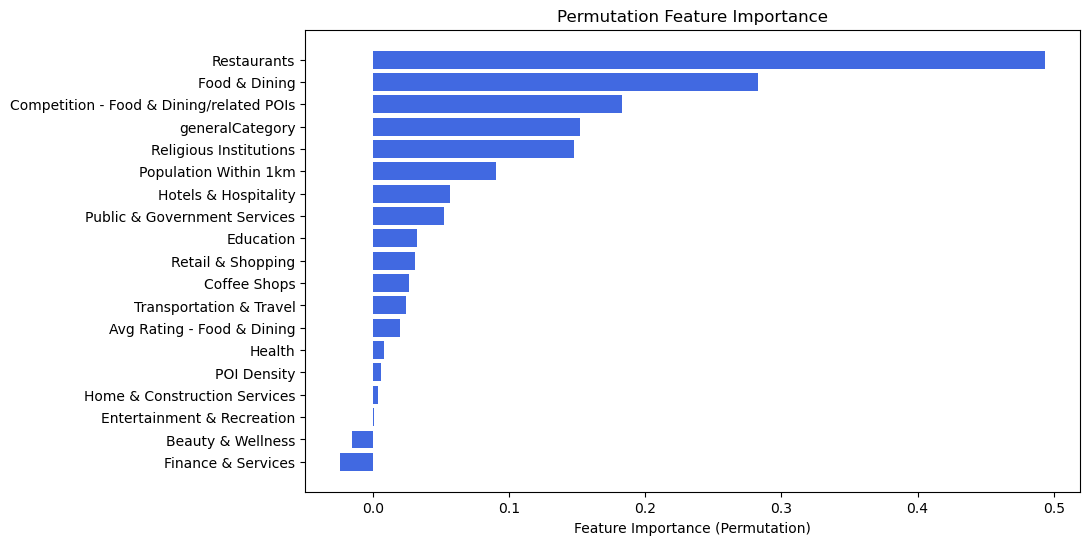

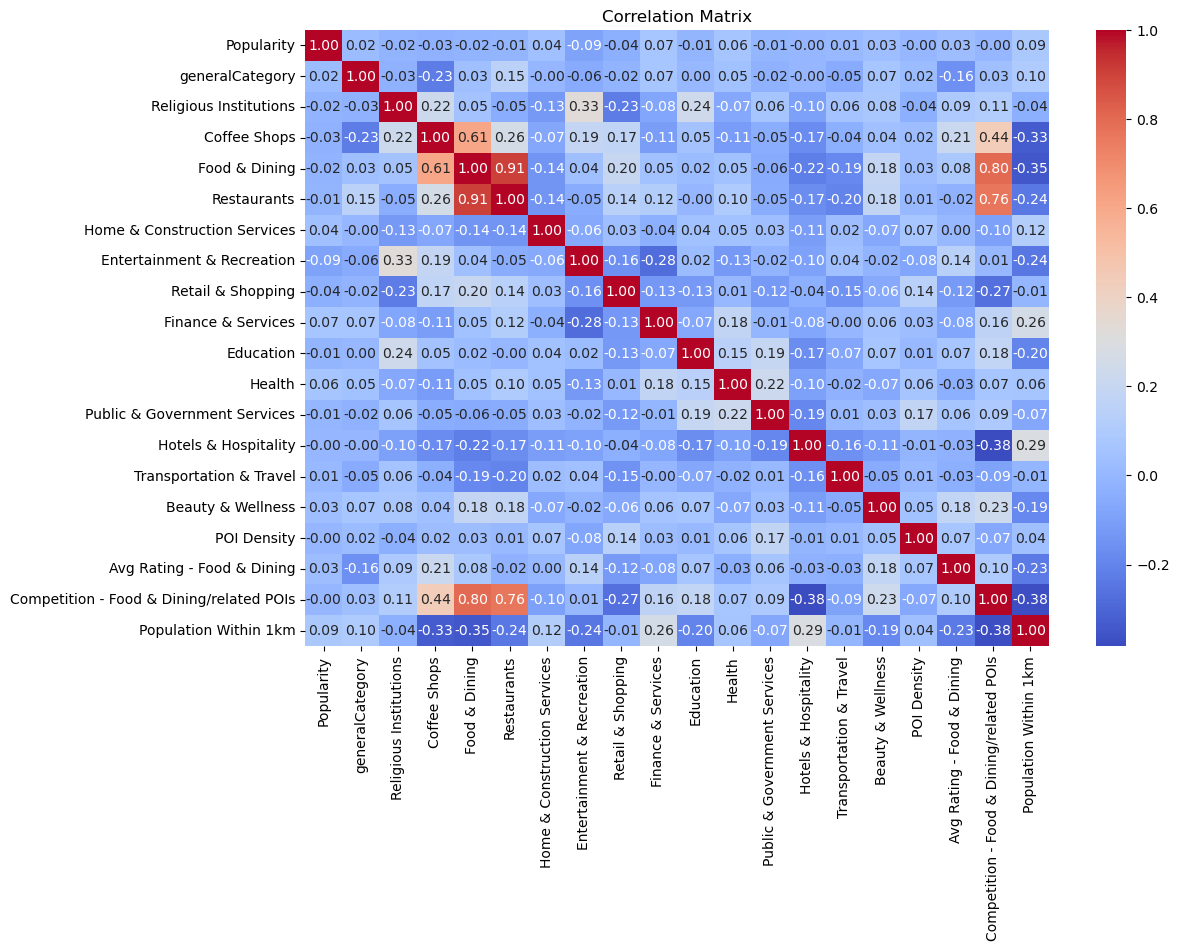

In [ ]:
combined_dropped = combined_df.drop(columns=["Competition - Business Type/Area",
                                        "Competition - Food & Dining/Area",
                                        "Competition - Business Type/POI Density",
                                        "Competition - Food & Dining/POI Density",
                                        "Competition - Business Type/related POIs",
                                        "Avg Rating - Business Type"])
trained_model = train_svr_with_feature_importance(combined_dropped)

# Compute the correlation matrix
corr_matrix = combined_dropped.corr()
 
# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Correlation Matrix")
plt.show()

After dropping Food & Dining

Final Metrics Comparison Table:
╒════╤══════════════════════════════════════════╤════════════════════════════╤════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤═════════════╤══════════╕
│    │ Competition Factor                       │ Rating Factor              │ Used Columns                                                                                                                                                                                                                                                                      

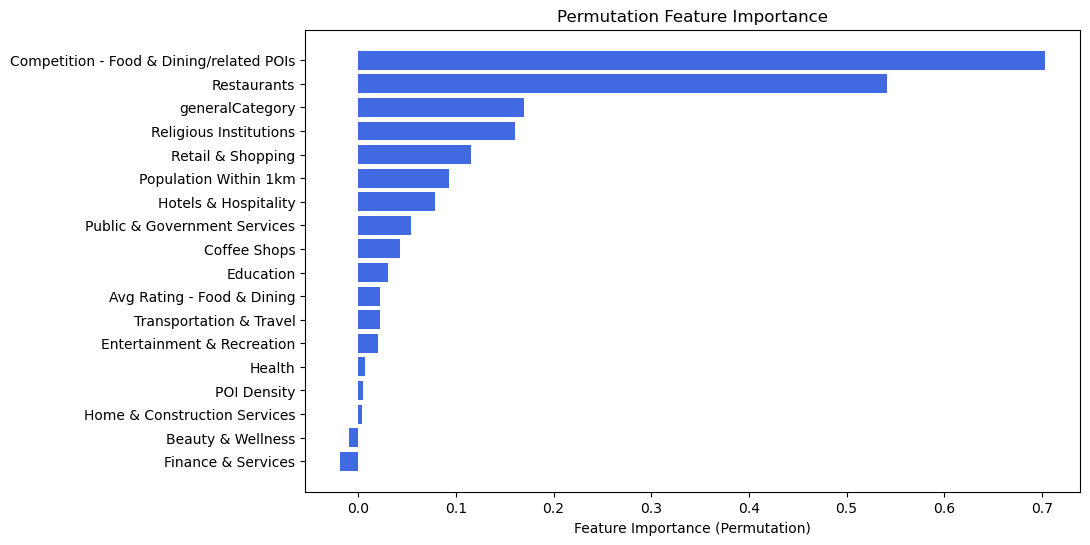

After dropping Restaurants and Coffee Shops

Final Metrics Comparison Table:
╒════╤══════════════════════════════════════════╤════════════════════════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤═════════════╤══════════╕
│    │ Competition Factor                       │ Rating Factor              │ Used Columns                                                                                                                                                                                                                                                                     

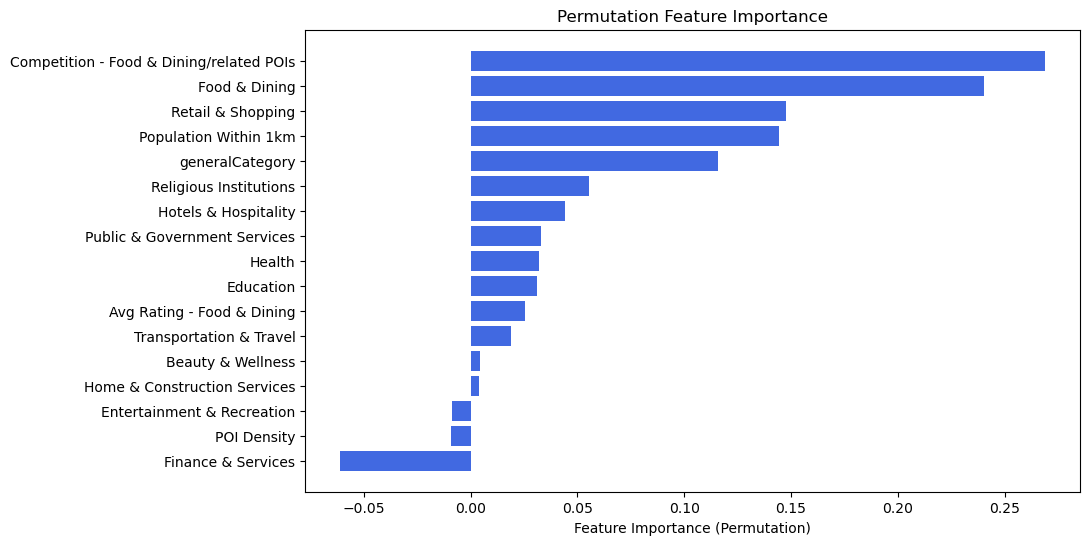

After dropping Restaurants, Coffee Shops and Food & Dining

Final Metrics Comparison Table:
╒════╤══════════════════════════════════════════╤════════════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤═════════════╤══════════╕
│    │ Competition Factor                       │ Rating Factor              │ Used Columns                                                                                                                                                                                                                                                                       

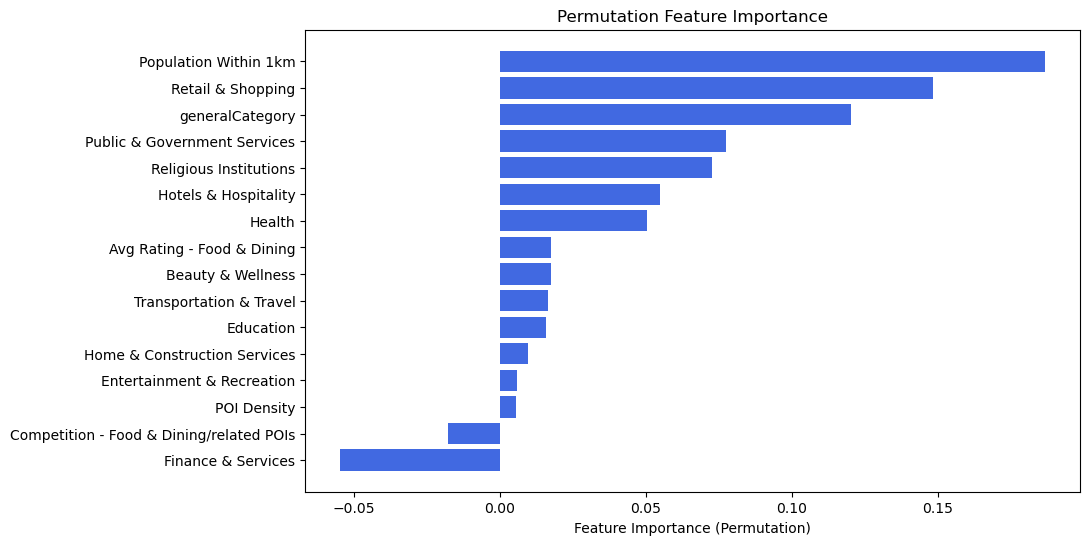

In [ ]:
print("After dropping Food & Dining")
combined_df_food = combined_dropped.drop(columns=["Food & Dining"])
trained_model = train_svr_with_feature_importance(combined_df_food)

print("After dropping Restaurants and Coffee Shops")
combined_df_restCoff = combined_dropped.drop(columns=["Restaurants", "Coffee Shops"])
trained_model = train_svr_with_feature_importance(combined_df_restCoff)

print("After dropping Restaurants, Coffee Shops and Food & Dining")
combined_df_restCoffFood = combined_dropped.drop(columns=["Restaurants", "Coffee Shops", "Food & Dining"])
trained_model = train_svr_with_feature_importance(combined_df_restCoffFood)

After dropping Food & Dining and POI Desity

Final Metrics Comparison Table:
╒════╤══════════════════════════════════════════╤════════════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤═════════════╤══════════╕
│    │ Competition Factor                       │ Rating Factor              │ Used Columns                                                                                                                                                                                                                                                                      

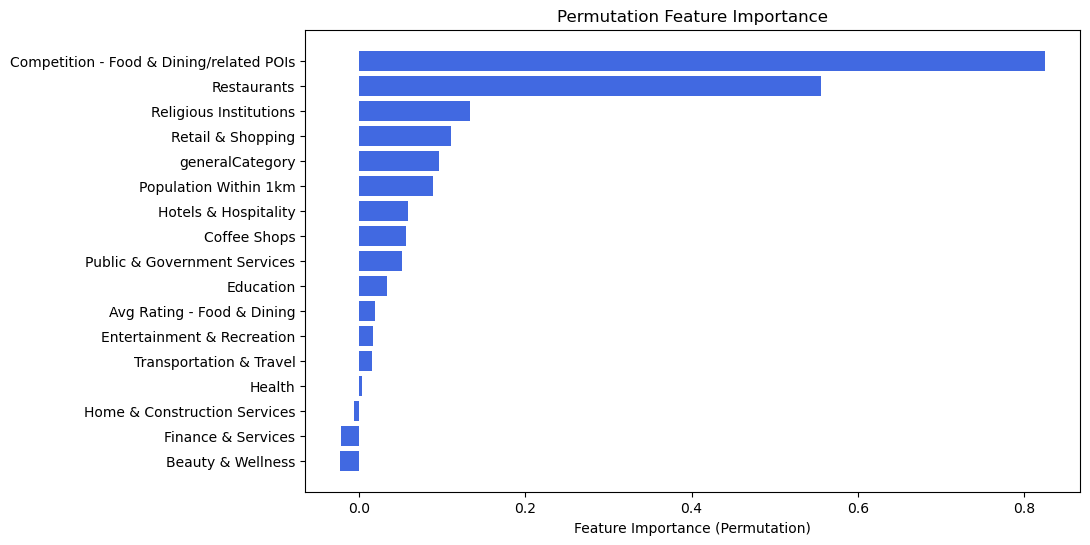

In [ ]:
print("After dropping Food & Dining and POI Desity")
combied_dropped = combined_dropped.drop(columns=['Food & Dining', 'POI Density'])
trained_model = train_svr_with_feature_importance(combied_dropped)

# Best result (4 factors)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr, kendalltau
import matplotlib.pyplot as plt
from tabulate import tabulate

def train_svr_with_feature_importance_diff(df):
    results = []

    # Define specific competition and rating factors
    target_competition = "Competition - Food & Dining/related POIs"
    target_rating = "Avg Rating - Food & Dining"

    # Identify available features
    available_features = [col for col in [target_competition, target_rating] if col in df.columns]

    if not available_features:
        print(f"Error: Neither '{target_competition}' nor '{target_rating}' found in DataFrame. Using all available features except 'Popularity'.")
        X = df.drop(columns=['Popularity'], errors='ignore')  # Use all features
    else:
        # Drop other competition & rating columns while keeping the selected ones
        X = df.drop(columns=['Popularity'] + 
                    [c for c in competition_cols if c != target_competition] + 
                    [r for r in avg_rating_cols if r != target_rating], 
                    errors='ignore')

    y = df['Popularity']

    # Step 1: Remove Outliers (IQR Method)
    X, y = remove_outliers_IQR(X, y)

    # Step 2: Remove Highly Correlated Features
    X = remove_highly_correlated_features(X)

    # Step 3: Apply MinMax Scaling
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Step 4: Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Step 5: Train SVR Model
    model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.05)
    model.fit(X_train, y_train)

    # Step 6: Predictions
    y_pred = model.predict(X_test)

    # Step 7: Compute Metrics
    metrics = {
        "Competition Factor": target_competition if target_competition in df.columns else "N/A",
        "Rating Factor": target_rating if target_rating in df.columns else "N/A",
        "Used Columns": list(X.columns),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R²": r2_score(y_test, y_pred),
        "MedAE": median_absolute_error(y_test, y_pred),
        "Max Error": max_error(y_test, y_pred),
        "MAD": np.median(np.abs(y_test - np.median(y_test))) 
    }
    results.append(metrics)

    # Print the metrics table
    print("\nFinal Metrics Comparison Table:")
    print(tabulate(pd.DataFrame(results), headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))

    # Step 8: Compute Permutation Feature Importance
    print(f"\nComputing feature importance for {target_competition} & {target_rating}...")
    perm_importance = permutation_importance(model, X_test, y_test, scoring='r2', n_repeats=10, random_state=42)

    # Plot Feature Importance
    sorted_idx = perm_importance.importances_mean.argsort()
    plt.figure(figsize=(10, 6))
    plt.barh(np.array(X.columns)[sorted_idx], perm_importance.importances_mean[sorted_idx], color='royalblue')
    plt.xlabel("Feature Importance (Permutation)")
    plt.title("Permutation Feature Importance")
    plt.show()

    # Step 9: Compute Correlation Metrics on Test Set
    print("\nCorrelation Metrics between Features and Popularity:")

    correlation_metrics = {}
    
    # Compute correlation for each feature with the target variable
    for i, feature in enumerate(X.columns):
        # Pearson correlation
        pearson_corr = np.corrcoef(X_test[:, i], y_test)[0, 1]
        
        # Spearman correlation
        spearman_corr, _ = spearmanr(X_test[:, i], y_test)
        
        # Kendall Tau correlation
        kendall_corr, _ = kendalltau(X_test[:, i], y_test)
        
        correlation_metrics[feature] = {
            "Pearson Correlation": pearson_corr,
            "Spearman Correlation": spearman_corr,
            "Kendall Tau": kendall_corr
        }

    # Print the correlation values
    for feature, metrics in correlation_metrics.items():
        print(f"\nFeature: {feature}")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.6f}")

    return model  # Return trained model



Final Metrics Comparison Table:
╒════╤══════════════════════════════════════════╤════════════════════════════╤════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤═════════════╤══════════╕
│    │ Competition Factor                       │ Rating Factor              │ Used Columns                                                                                                       │     RMSE │      MSE │      MAE │        R² │    MedAE │   Max Error │      MAD │
╞════╪══════════════════════════════════════════╪════════════════════════════╪════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╪══════════╪══════════╪══════════╪═══════════╪══════════╪═════════════╪══════════╡
│  0 │ Competition - Food & Dining/related POIs │ Avg Rating - Food & Dining │ ['POI Density', 'Avg Rating - Food & Dining', 'Competitio

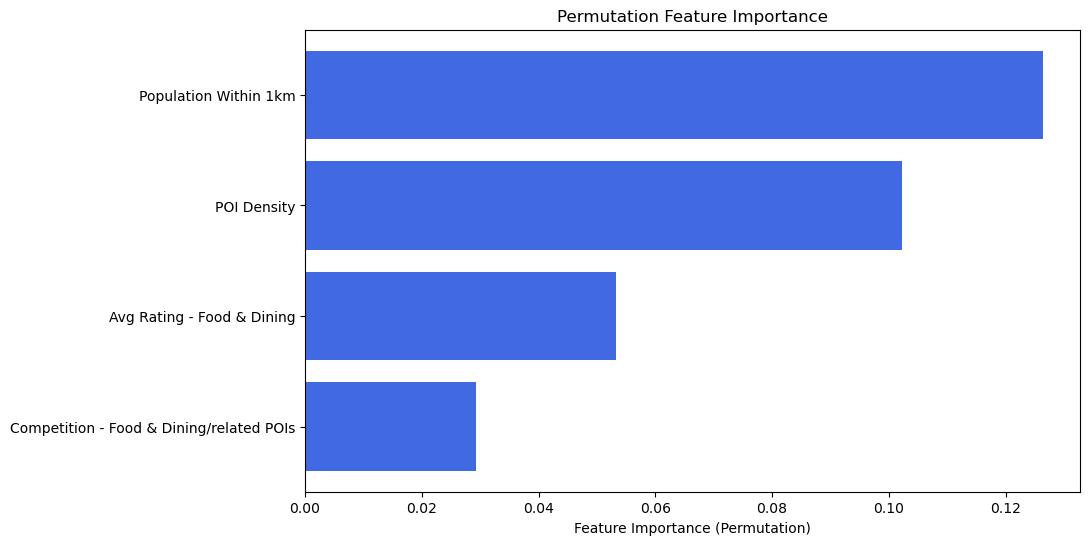


Correlation Metrics between Features and Popularity:

Feature: POI Density
Pearson Correlation: 0.014334
Spearman Correlation: -0.029532
Kendall Tau: -0.022167

Feature: Avg Rating - Food & Dining
Pearson Correlation: 0.059155
Spearman Correlation: 0.083113
Kendall Tau: 0.056648

Feature: Competition - Food & Dining/related POIs
Pearson Correlation: -0.016326
Spearman Correlation: -0.002972
Kendall Tau: -0.002461

Feature: Population Within 1km
Pearson Correlation: 0.033671
Spearman Correlation: -0.039257
Kendall Tau: -0.030528


In [ ]:
combied_dropped = combined_dropped.drop(columns=['generalCategory','Food & Dining', 'Religious Institutions', 'Coffee Shops', 'Restaurants', 'Home & Construction Services', 'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services', 'Education', 'Health', 'Public & Government Services', 'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness'])
trained_model = train_svr_with_feature_importance_diff(combied_dropped)

## Grid Search 

### Grid Search on the best result

In [ ]:
# Define hyperparameter grid for SVR
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 2, 10],
    'epsilon': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]
}

results = []

# Replace with your actual DataFrame
X = combied_dropped.drop(columns=['Popularity'], errors='ignore')
y = combined_df['Popularity']

print(f"Using features: {list(X.columns)}")  # Print selected features

# Apply MaxAbsScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize SVR model
svr = SVR(kernel='rbf')

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, return_train_score=True)
grid_search.fit(X_train, y_train)

# Get results for each parameter combination
cv_results = grid_search.cv_results_

# Store results for each parameter combination
for i in range(len(cv_results['params'])):
    metrics = {
        "Params": cv_results["params"][i],
        "Mean Train MSE": -cv_results["mean_train_score"][i],  # Convert negative MSE back to positive
        "Mean CV MSE": -cv_results["mean_test_score"][i],  # Convert negative MSE back to positive
        "Std Dev CV MSE": cv_results["std_test_score"][i],
    }
    results.append(metrics)

# Convert results to DataFrame and print
results_df = pd.DataFrame(results)
print("\nGrid Search Results for Each Parameter Combination:")
print(tabulate(results_df, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))

# Get the best model
best_model = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")

# Predict using the best model
y_pred = best_model.predict(X_test)

# Compute final metrics
final_metrics = {
    "Best Params": grid_search.best_params_,
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "MSE": mean_squared_error(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "R²": r2_score(y_test, y_pred),
    "MedAE": median_absolute_error(y_test, y_pred),
    "Max Error": max_error(y_test, y_pred),
    "MAD": np.median(np.abs(y_test - np.median(y_test)))
}

# Print final best model metrics
final_metrics_df = pd.DataFrame([final_metrics])
print("\nFinal Best Model Metrics:")
print(tabulate(final_metrics_df, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))


Using features: ['POI Density', 'Avg Rating - Food & Dining', 'Competition - Food & Dining/related POIs', 'Population Within 1km']

Grid Search Results for Each Parameter Combination:
╒═════╤═════════════════════════════════════════════════╤══════════════════╤═══════════════╤══════════════════╕
│     │ Params                                          │   Mean Train MSE │   Mean CV MSE │   Std Dev CV MSE │
╞═════╪═════════════════════════════════════════════════╪══════════════════╪═══════════════╪══════════════════╡
│   0 │ {'C': 0.01, 'epsilon': 0.001, 'gamma': 'scale'} │         0.040949 │      0.041020 │         0.006087 │
├─────┼─────────────────────────────────────────────────┼──────────────────┼───────────────┼──────────────────┤
│   1 │ {'C': 0.01, 'epsilon': 0.001, 'gamma': 'auto'}  │         0.041037 │      0.041053 │         0.006103 │
├─────┼─────────────────────────────────────────────────┼──────────────────┼───────────────┼──────────────────┤
│   2 │ {'C': 0.01, 'epsilon': 0

### Grid search on all the featurs 

In [ ]:
# Define hyperparameter grid for SVR
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],  
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 2, 10],  
    'epsilon': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]  
}


results = []

for col in competition_cols:
    for rating_col in avg_rating_cols:
        if col not in combined_df.columns:
            continue

        X = combined_df.drop(columns=['Popularity'] + [c for c in competition_cols if c != col] + [r for r in avg_rating_cols if r != rating_col], errors='ignore')
        y = combined_df['Popularity']

        print(f"Using features for {col}: {list(X.columns)}")  # Print considered factors

        
        X_scaler = MinMaxScaler()
        X_scaled = X_scaler.fit_transform(X)

       
        y_scaled = y.values  

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

        # Initialize SVR model
        svr = SVR(kernel='rbf')

        # Perform Grid Search with 5-fold cross-validation
        grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        # Get the best SVR model
        best_model = grid_search.best_estimator_
        print(f"Best Parameters for {col}: {grid_search.best_params_}")

        # Predict using the best model
        y_pred = best_model.predict(X_test)

        # Compute metrics
        metrics = {
            "Competition Factor": col,
            "Rating Factor": rating_col,
            "columns": list(X.columns),
            "Best Params": grid_search.best_params_,
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MSE": mean_squared_error(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R²": r2_score(y_test, y_pred),
            "MedAE": median_absolute_error(y_test, y_pred),
            "Max Error": max_error(y_test, y_pred),
            "MAD": np.median(np.abs(y_test - np.median(y_test))) 
        }
        results.append(metrics)

# Convert results to DataFrame and print
metrics_df = pd.DataFrame(results)
print("\nFinal Metrics Comparison Table:")
print(tabulate(metrics_df, headers="keys", tablefmt="fancy_grid", floatfmt=".6f"))


### Old code of grid search 

In [ ]:
results = []

for rating_col in avg_rating_cols:  
    for comp_col in competition_cols:
        if rating_col not in combined_df.columns or comp_col not in combined_df.columns:
            continue 

        extra_features = ["Restaurants", "Coffee Shops", "Health", "Education", "Retail & Shopping", "Entertainment & Recreation", 
                      "Food & Dining", "Hotels & Hospitality", "Finance & Services", 
                      "Transportation & Travel", "Public & Government Services", "Religious Institutions",
                      "Beauty & Wellness", "Home & Construction Services", "POI Density", "Population Within 1km"]

        selected_features = [comp_col, rating_col] + [f for f in extra_features if f in combined_df.columns]

        if not all(col in combined_df.columns for col in selected_features):
            raise ValueError("One or more selected features are missing from the DataFrame.")
        
        print(f"Using Features: {selected_features}")

        X = combined_df[selected_features]
        y = combined_df[target_col]

        X_scaler = StandardScaler()
        y_scaler = StandardScaler()
        X_scaled = X_scaler.fit_transform(X)
        y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

        svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
        svr_model.fit(X_train, y_train)

        y_pred = svr_model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        medae = median_absolute_error(y_test, y_pred)
        max_err = max_error(y_test, y_pred)
        mad = np.median(np.abs(y_test - np.median(y_test)))  

        results.append([f"{selected_features}", rmse, mse, mae, r2, medae, max_err, mad])

metrics_df = pd.DataFrame(results, columns=[
    "Competition & Rating Factor", "RMSE", "MSE", "MAE", "R²", "MedAE", "Max Error", "MAD"
])

print("\nFinal Metrics Comparison Table:\n")
print(tabulate(metrics_df, headers='keys', tablefmt='fancy_grid', floatfmt=".6f"))

# SHAP Analysis using KernelExplainer
def model_predict(X):
    return svr_model.predict(X)

explainer = shap.KernelExplainer(model_predict, X_train)  
shap_values = explainer.shap_values(X_test) 

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X.columns)
plt.show()


Using Features: ['Competition - Business Type/Area', 'Avg Rating - Business Type', 'Restaurants', 'Coffee Shops', 'Health', 'Education', 'Retail & Shopping', 'Entertainment & Recreation', 'Food & Dining', 'Hotels & Hospitality', 'Finance & Services', 'Transportation & Travel', 'Public & Government Services', 'Religious Institutions', 'Beauty & Wellness', 'Home & Construction Services', 'POI Density', 'Population Within 1km']
Using Features: ['Competition - Food & Dining/Area', 'Avg Rating - Business Type', 'Restaurants', 'Coffee Shops', 'Health', 'Education', 'Retail & Shopping', 'Entertainment & Recreation', 'Food & Dining', 'Hotels & Hospitality', 'Finance & Services', 'Transportation & Travel', 'Public & Government Services', 'Religious Institutions', 'Beauty & Wellness', 'Home & Construction Services', 'POI Density', 'Population Within 1km']
Using Features: ['Competition - Business Type/POI Density', 'Avg Rating - Business Type', 'Restaurants', 'Coffee Shops', 'Health', 'Education'

NameError: name 'shap' is not defined

Using Features: ['Competition - Business Type/Area', 'Avg Rating - Business Type', 'POI Density', 'Population Within 1km']
Using Features: ['Competition - Food & Dining/Area', 'Avg Rating - Business Type', 'POI Density', 'Population Within 1km']
Using Features: ['Competition - Business Type/POI Density', 'Avg Rating - Business Type', 'POI Density', 'Population Within 1km']
Using Features: ['Competition - Food & Dining/POI Density', 'Avg Rating - Business Type', 'POI Density', 'Population Within 1km']
Using Features: ['Competition - Business Type/related POIs', 'Avg Rating - Business Type', 'POI Density', 'Population Within 1km']
Using Features: ['Competition - Food & Dining/related POIs', 'Avg Rating - Business Type', 'POI Density', 'Population Within 1km']
Using Features: ['Competition - Business Type/Area', 'Avg Rating - Food & Dining', 'POI Density', 'Population Within 1km']
Using Features: ['Competition - Food & Dining/Area', 'Avg Rating - Food & Dining', 'POI Density', 'Population

Using 1528 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.



Final Metrics Comparison Table:

╒════╤════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤══════════╤══════════╤══════════╤═══════════╤══════════╤═════════════╤══════════╕
│    │ Competition & Rating Factor                                                                                        │     RMSE │      MSE │      MAE │        R² │    MedAE │   Max Error │      MAD │
╞════╪════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╪══════════╪══════════╪══════════╪═══════════╪══════════╪═════════════╪══════════╡
│  0 │ ['Competition - Business Type/Area', 'Avg Rating - Business Type', 'POI Density', 'Population Within 1km']         │ 0.880281 │ 0.774894 │ 0.346025 │ -0.068969 │ 0.132439 │    5.097702 │ 0.099986 │
├────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼──────────┼──────────┼─

  0%|          | 0/382 [00:00<?, ?it/s]

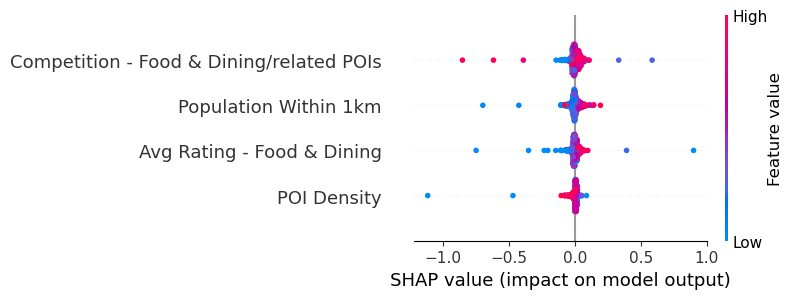

In [ ]:
results = []

for rating_col in avg_rating_cols:  
    for comp_col in competition_cols:
        if rating_col not in combined_df.columns or comp_col not in combined_df.columns:
            continue 

        extra_features = ["Restaurants", "Coffee Shops", "Health", "Education", "Retail & Shopping", "Entertainment & Recreation", 
                      "Food & Dining", "Hotels & Hospitality", "Finance & Services", 
                      "Transportation & Travel", "Public & Government Services", "Religious Institutions",
                      "Beauty & Wellness", "Home & Construction Services", "POI Density", "Population Within 1km"]

        selected_features = [comp_col, rating_col] + [f for f in extra_features if f in combined_df.columns]

        if not all(col in combined_df.columns for col in selected_features):
            raise ValueError("One or more selected features are missing from the DataFrame.")
        
        print(f"Using Features: {selected_features}")

        X = combined_df[selected_features]
        y = combined_df[target_col]

        X_scaler = StandardScaler()
        y_scaler = StandardScaler()
        X_scaled = X_scaler.fit_transform(X)
        y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

        svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
        svr_model.fit(X_train, y_train)

        y_pred = svr_model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        medae = median_absolute_error(y_test, y_pred)
        max_err = max_error(y_test, y_pred)
        mad = np.median(np.abs(y_test - np.median(y_test)))  

        results.append([f"{selected_features}", rmse, mse, mae, r2, medae, max_err, mad])

metrics_df = pd.DataFrame(results, columns=[
    "Competition & Rating Factor", "RMSE", "MSE", "MAE", "R²", "MedAE", "Max Error", "MAD"
])

print("\nFinal Metrics Comparison Table:\n")
print(tabulate(metrics_df, headers='keys', tablefmt='fancy_grid', floatfmt=".6f"))

# SHAP Analysis using KernelExplainer
def model_predict(X):
    return svr_model.predict(X)

explainer = shap.KernelExplainer(model_predict, X_train)  
shap_values = explainer.shap_values(X_test) 

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X.columns)
plt.show()


## SVR with all features

In [ ]:
best_comp_col = "Competition - Food & Dining/POI Density"
best_rating_col = "Avg Rating - Food & Dining"

extra_features = ["POI Density", "Population Within 1km"]

selected_features = [best_comp_col, best_rating_col] + [f for f in extra_features if f in combined_df.columns]

if not all(col in combined_df.columns for col in selected_features):
    raise ValueError("One or more selected features are missing from the DataFrame.")

print(f"Using Features: {selected_features}")

X = combined_df[selected_features].values
y = combined_df[target_col].values

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid = {
    'svr__kernel': ['rbf', 'linear', 'poly'],
    'svr__C': [1, 10, 50, 100, 200],  
    'svr__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svr__epsilon': [0.01, 0.1, 0.2, 0.5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X, y)

best_model = grid_search.best_estimator_

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_squared_error')
final_rmse = np.sqrt(-cv_scores.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.median(np.abs(y_test - np.median(y_test)))

metrics_df = pd.DataFrame([
    ["Optimized SVR Model", final_rmse, mse, mae, r2, medae, max_err, mad]
], columns=["Model", "RMSE (CV)", "MSE", "MAE", "R²", "MedAE", "Max Error", "MAD"])

print("\nFinal Optimized Model Performance Metrics:\n")
print(tabulate(metrics_df, headers='keys', tablefmt='fancy_grid', floatfmt=".6f"))

print("\nBest Hyperparameters:", grid_search.best_params_)


Using Features: ['Competition - Food & Dining/POI Density', 'Avg Rating - Food & Dining', 'POI Density', 'Population Within 1km']


NameError: name 'Pipeline' is not defined

## Method

In [ ]:
def svr_model(df, target_column):
    # Ensure the target column exists in the DataFrame
    if target_column not in df.columns:
        raise ValueError("Target column not found in DataFrame")
    
    # Separate features and target
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    # Print feature names
    feature_names = list(X.columns)
    print("Feature names:", feature_names)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Initialize and train SVR model
    svr = SVR(kernel='rbf')
    svr.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = svr.predict(X_test_scaled)
    
   # Compute evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)
    max_err = max_error(y_test, y_pred)
    
    # Create results DataFrame
    results_df = pd.DataFrame({
        "Metric": ["RMSE", "MSE", "MAE", "R2 Score", "MedAE", "Max Error"],
        "Value": [rmse, mse, mae, r2, medae, max_err]
    })
    
    print("\nResults:")
    print(results_df.to_markdown(index=False))
    
    return svr


In [ ]:
# Example usage:
file_path = "../Foursquare/final_restaurants_dataset_cleaned.csv"  
df = pd.read_csv(file_path)
df.drop(columns=['Business ID'], inplace=True)
df.drop(columns=['Name'],inplace=True)
df.drop(columns=['Latitude'],inplace=True)
df.drop(columns=['Longitude'],inplace=True)
df.drop(columns=['Rating'], inplace=True)
df.drop(columns=['Google Place ID'], inplace=True)
df.drop(columns=['Business Status'], inplace=True)
df.drop(columns=['Distance (m)'], inplace=True)
df.drop(columns=['Cluster'], inplace=True)

## ??
df.drop(columns=['Category'], inplace=True)
df = pd.get_dummies(df, columns=['generalCategory'], drop_first=True)  

df.drop(columns=['Avg Rating - Food & Dining'], inplace=True)
df.drop(columns=['Avg Rating - Restaurants'], inplace=True)
svr_model(df, target_column="Popularity")

Feature names: ['Religious Institutions', 'Coffee Shops', 'Food & Dining', 'Restaurants', 'Home & Construction Services', 'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services', 'Education', 'Health', 'Public & Government Services', 'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness', 'POI Density', 'Competition - Restaurants/Area', 'Competition - Food & Dining/Area', 'Competition - Restaurants/POI Density', 'Competition - Food & Dining/POI Density', 'Competition - Restaurants/related POIs', 'Competition - Food & Dining/related POIs', 'Population Within 1km']

Results:
| Metric    |      Value |
|:----------|-----------:|
| RMSE      |  0.173036  |
| MSE       |  0.0299415 |
| MAE       |  0.102063  |
| R2 Score  | -0.108092  |
| MedAE     |  0.0735857 |
| Max Error |  0.909031  |


SVR()